# EDA: California Housing

**Датасет:** California Housing — 20 640 записей, 8 числовых признаков, целевая переменная `MedHouseVal` (медианная стоимость дома, ×100k $).

**Шаги:**
1. Матрица корреляций (phik) всех признаков между собой.
2. Удаление выбросов по IQR, пересчёт корреляций.
3. Корреляция каждого признака с `MedHouseVal` (ранжирование).
4. Scatter-графики (regplot) — визуальная оценка линейных связей.
5. Box-графики — распределение признаков по бинам `MedHouseVal`.

In [1]:
!pip install numpy pandas scikit-learn seaborn phik

In [2]:
import phik
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
mpl.rcParams['figure.constrained_layout.use'] = True

In [4]:
from sklearn.datasets import fetch_california_housing

df = fetch_california_housing(as_frame=True).frame

df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


interval columns not set, guessing: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


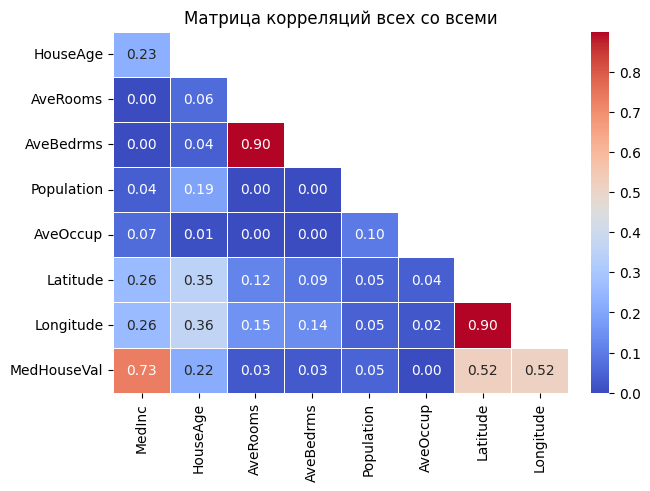

In [5]:
phik_matrix = df.phik_matrix()
phik_matrix_for_heatmap = phik_matrix.drop(columns='MedHouseVal', index='MedInc')
plt.title('Матрица корреляций всех со всеми')
sns.heatmap(
    phik_matrix_for_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    mask=np.triu(np.ones_like(phik_matrix_for_heatmap, dtype=bool),k=1)
)
plt.show()

interval columns not set, guessing: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


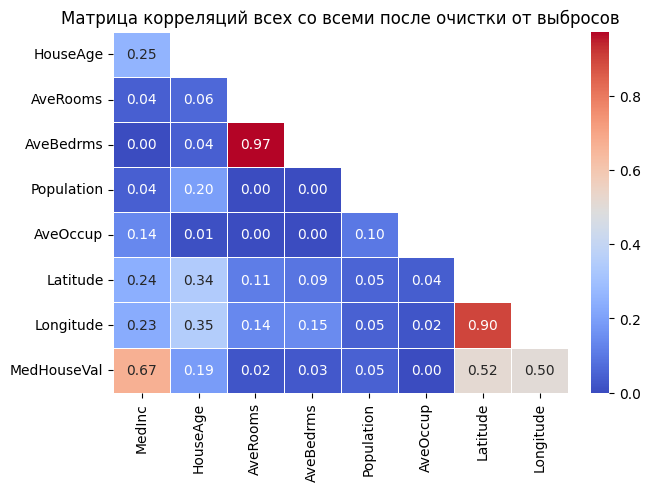

In [6]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_cleaned = df[(df[col] > lower) & (df[col] < upper)]

phik_matrix = df_cleaned.phik_matrix()
phik_matrix_for_heatmap = phik_matrix.drop(columns='MedHouseVal', index='MedInc')
plt.title('Матрица корреляций всех со всеми после очистки от выбросов')
sns.heatmap(
    phik_matrix_for_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    mask=np.triu(np.ones_like(phik_matrix_for_heatmap, dtype=bool),k=1)
)
plt.show()

In [7]:
df = df_cleaned

In [8]:
med_house_val_corr = phik_matrix_for_heatmap.loc[['MedHouseVal']].T.sort_values(by='MedHouseVal', ascending=False)

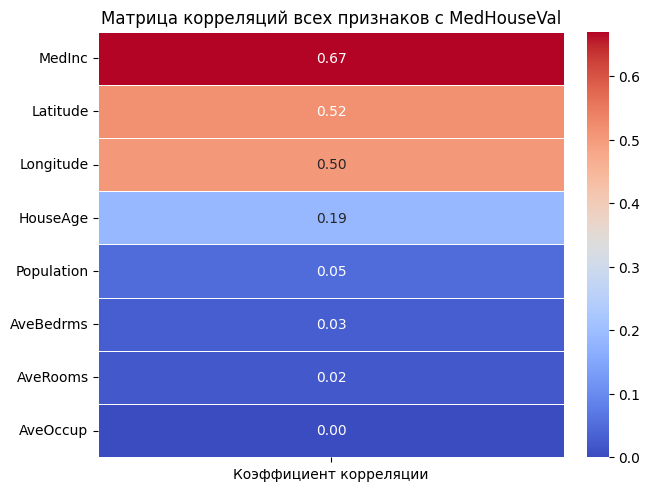

In [9]:
plt.title('Матрица корреляций всех признаков c MedHouseVal')
sns.heatmap(
    med_house_val_corr.rename(columns={'MedHouseVal': 'Коэффициент корреляции'}),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.show()

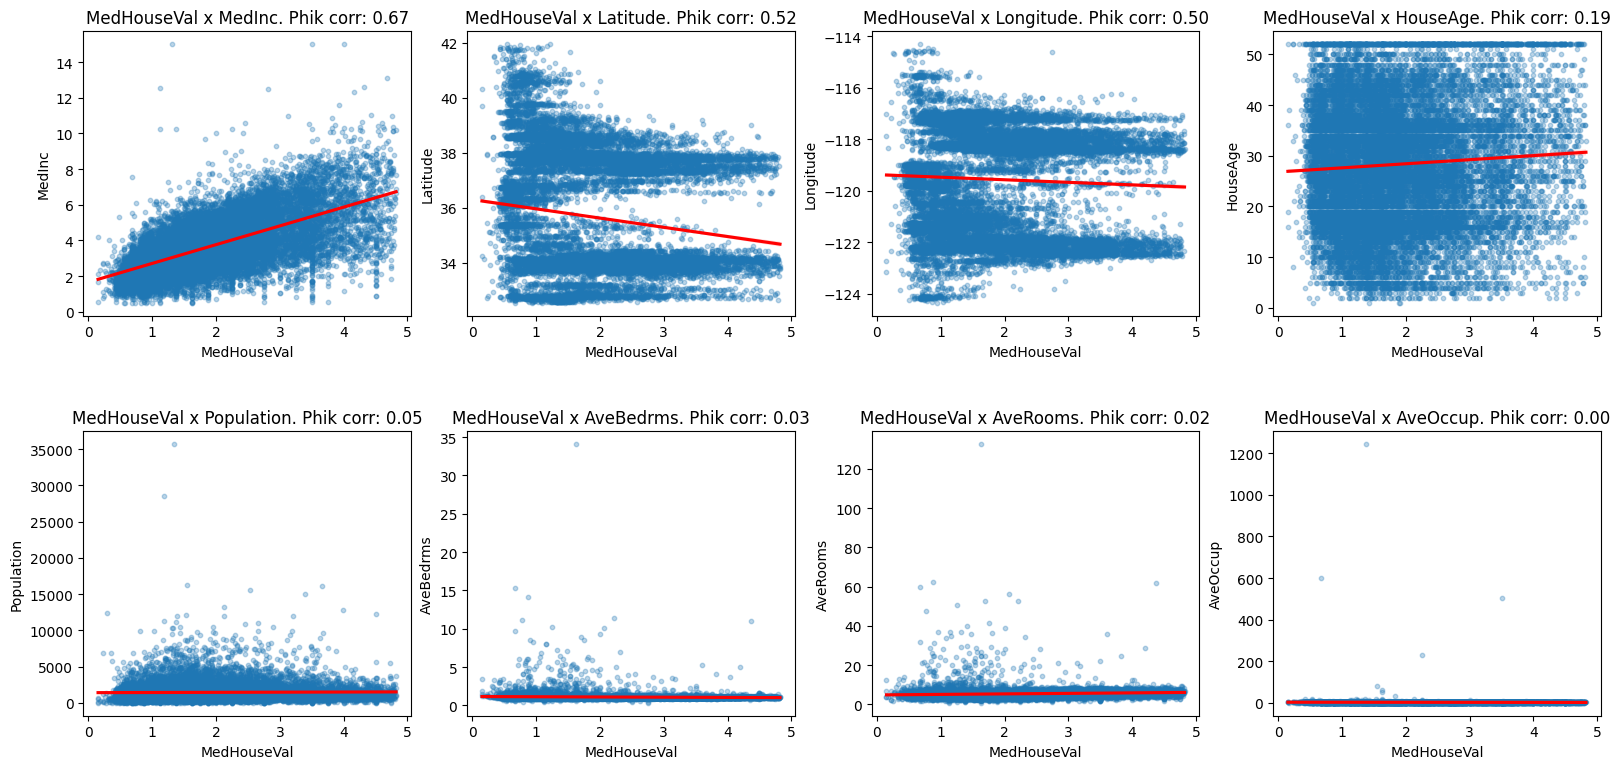

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

fig.set_constrained_layout_pads(
    h_pad=0.25,
)

for ax, attr in zip(axes.flatten(), med_house_val_corr.index):
    ax.set(title=f"MedHouseVal x {attr}. Phik corr: {med_house_val_corr.loc[attr]['MedHouseVal']:.2f}")
    sns.regplot(
        data=df,
        x='MedHouseVal',
        y=attr,
        scatter_kws={'alpha': 0.3, 's': 10},
        line_kws={'color': 'red'},
        ax=ax
    )

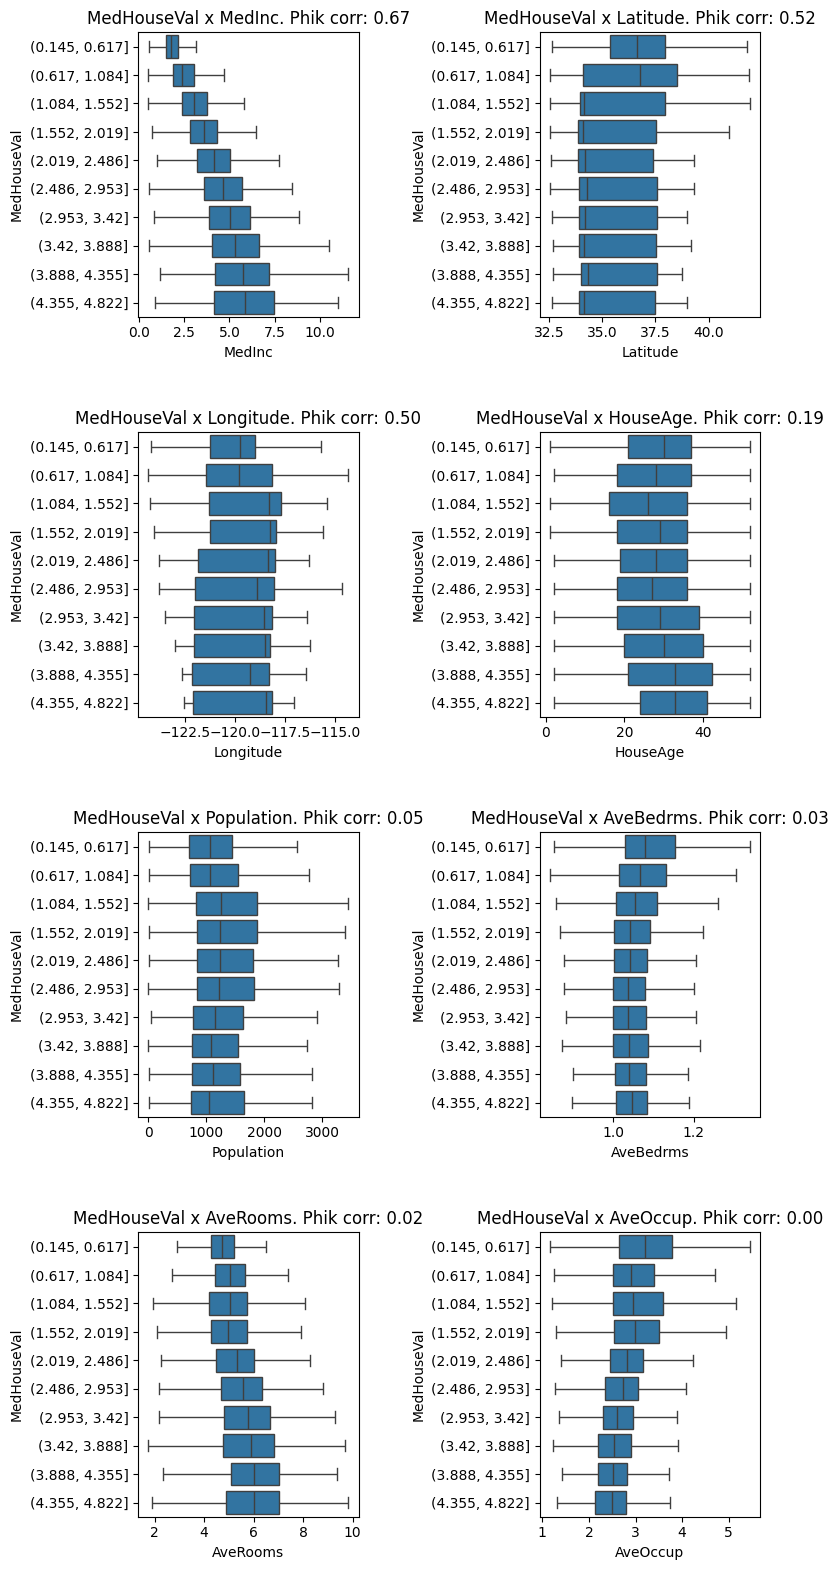

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(8, 16))

fig.set_constrained_layout_pads(
    h_pad=0.25,
    w_pad=0.25,
)

for ax, attr in zip(axes.flatten(), med_house_val_corr.index):
    ax.set(title=f"MedHouseVal x {attr}. Phik corr: {med_house_val_corr.loc[attr]['MedHouseVal']:.2f}")
    sns.boxplot(
        data=df,
        x=attr,
        y=pd.cut(df['MedHouseVal'], bins=10),
        ax=ax,
        showfliers=False
    )

## Выводы

- **`MedInc`** (медианный доход) — самый сильный предиктор `MedHouseVal`. Связь близка к линейной.
- **`Latitude` / `Longitude`** — география заметно влияет на стоимость (прибрежные районы дороже).
- **`AveRooms`** — умеренная положительная корреляция: больше комнат → дороже.
- **`HouseAge`** — слабая связь; возраст сам по себе не определяет цену.
- **`Population`, `AveOccup`, `AveBedrms`** — слабые предикторы после очистки выбросов.
- Удаление выбросов по IQR изменило корреляционную картину: часть ложных связей исчезла, структура данных стала чище.
- Scatter- и box-графики подтвердили, что линейная зависимость наиболее выражена для `MedInc`, для остальных признаков связь нелинейная или зашумлённая.